In [3]:
# ============================================================
# LGBM vs XGBoost on Diabetes Dataset
# ============================================================

# ============================================================
# 1. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [4]:
# ============================================================
# 2. Load Dataset
# ============================================================

df = pd.read_csv("diabetes.csv")

# Display first 5 rows
print(df.head())

# Dataset information
print("\nDataset Info:")
print(df.info())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose       

In [5]:
# ============================================================
# 3. Check Missing Values
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


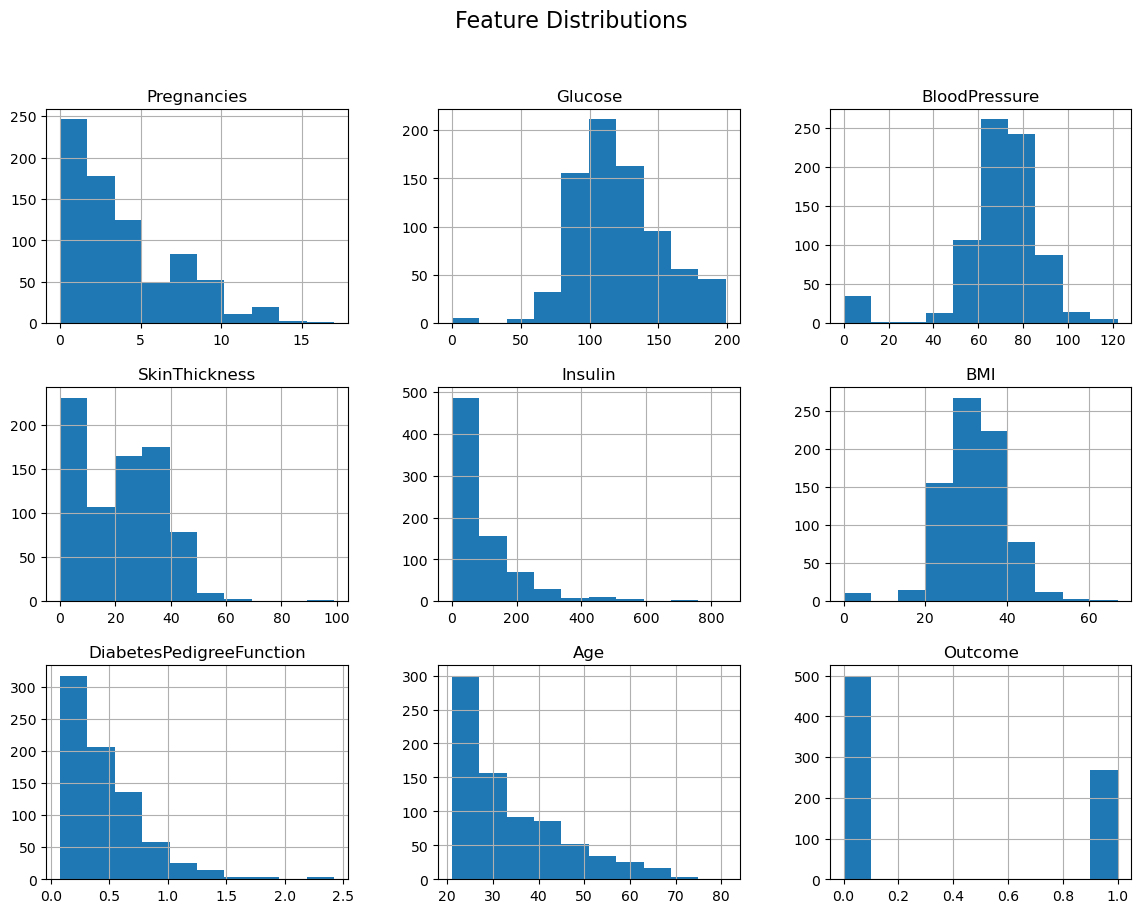

In [6]:
# ============================================================
# 4. Exploratory Data Analysis (EDA)
# ============================================================

# ---------------------------
# Histograms
# ---------------------------

df.hist(figsize=(14,10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()


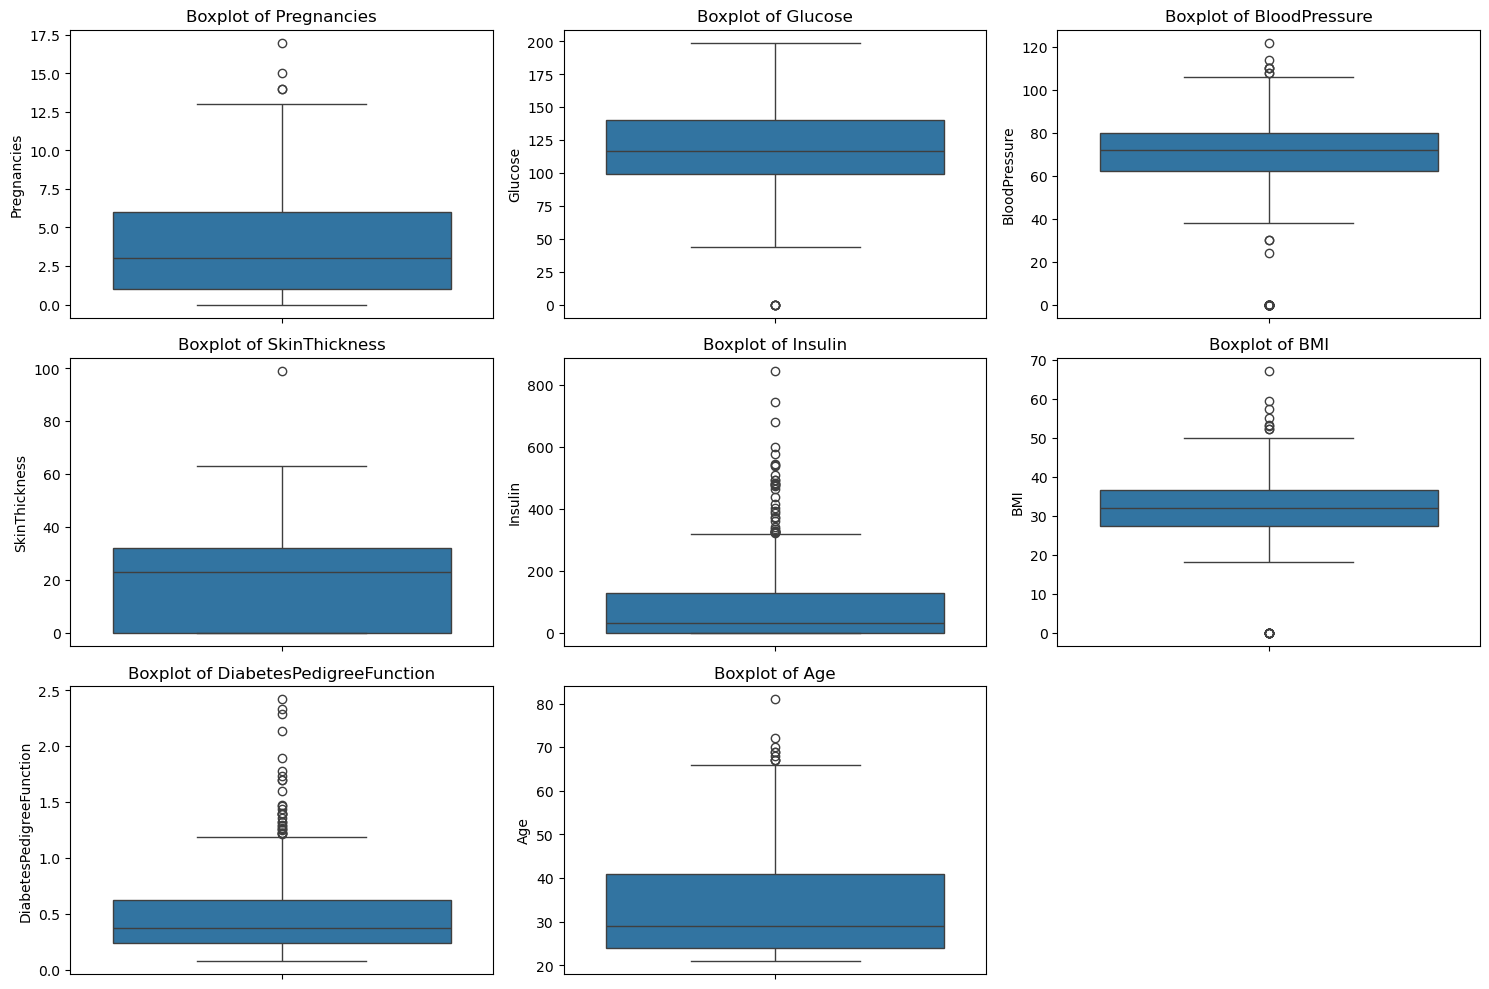

In [7]:
# ---------------------------
# Boxplots
# ---------------------------

plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[column])
    plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

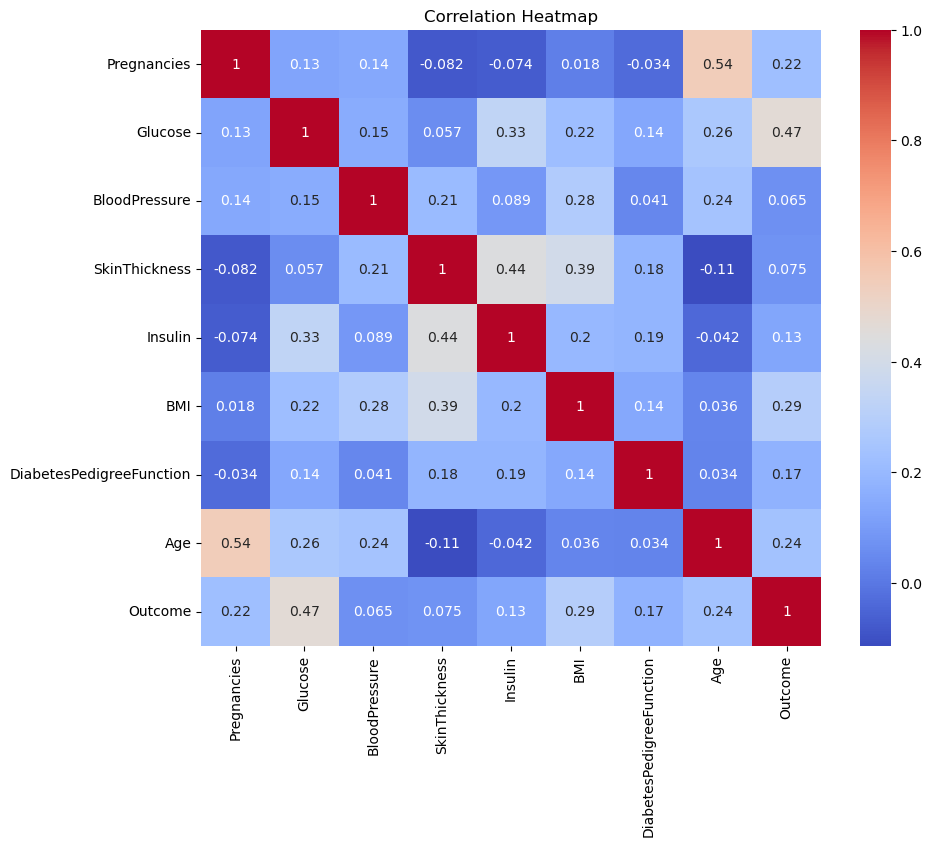

In [8]:
# ---------------------------
# Correlation Heatmap
# ---------------------------

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

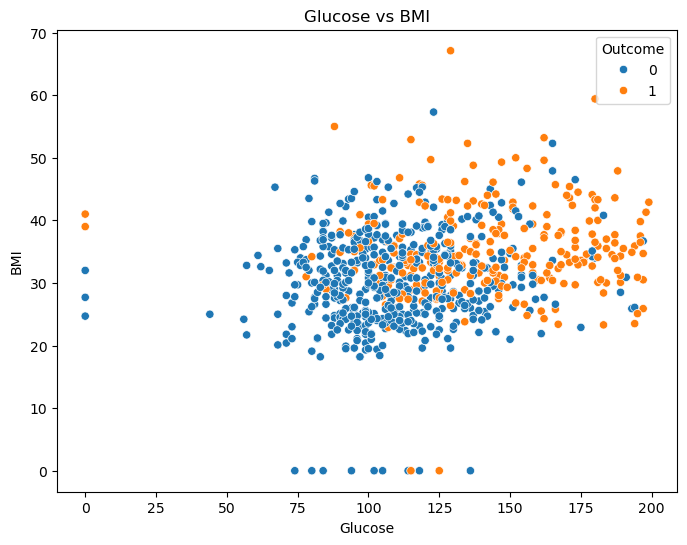

In [9]:
# ---------------------------
# Scatter Plot
# ---------------------------

plt.figure(figsize=(8,6))
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title("Glucose vs BMI")
plt.show()

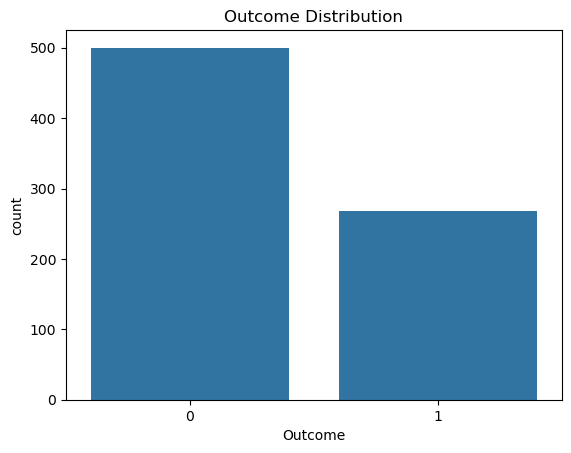

In [10]:
# ---------------------------
# Bar Plot
# ---------------------------

sns.countplot(x='Outcome', data=df)
plt.title("Outcome Distribution")
plt.show()


In [11]:
# ============================================================
# 5. Data Preprocessing
# ============================================================

# Replace invalid zeros with NaN
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_with_zero:
    df[col] = df[col].replace(0, np.nan)

# Check missing values again
print("\nMissing Values After Replacing Zeros:")
print(df.isnull().sum())


Missing Values After Replacing Zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [12]:
# ---------------------------
# Impute Missing Values
# ---------------------------

imputer = SimpleImputer(strategy='median')

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [13]:
# ---------------------------
# Feature Scaling
# ---------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)

In [14]:
# ============================================================
# 6. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [17]:
!pip install lightgbm
!pip install xgboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

In [18]:
# ============================================================
# 7. Build LightGBM Model
# ============================================================

lgbm_model = LGBMClassifier(random_state=42)

lgbm_model.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm_model.predict(X_test)

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [19]:
# ============================================================
# 8. Evaluate LightGBM Model
# ============================================================

print("\n========== LightGBM Results ==========")

print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgbm))


========== LightGBM Results ==========
Accuracy : 0.7272727272727273
Precision: 0.62
Recall   : 0.5740740740740741
F1 Score : 0.5961538461538461

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.79       100
           1       0.62      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



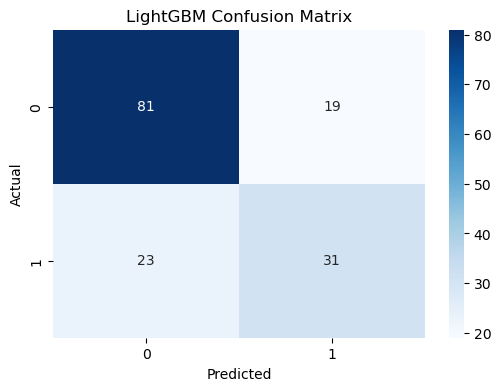

In [20]:
# Confusion Matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues')
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
# ============================================================
# 9. Build XGBoost Model
# ============================================================

xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
# Predictions
y_pred_xgb = xgb_model.predict(X_test)


In [23]:
# ============================================================
# 10. Evaluate XGBoost Model
# ============================================================

print("\n========== XGBoost Results ==========")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))



========== XGBoost Results ==========
Accuracy : 0.7597402597402597
Precision: 0.673469387755102
Recall   : 0.6111111111111112
F1 Score : 0.6407766990291263

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       100
           1       0.67      0.61      0.64        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



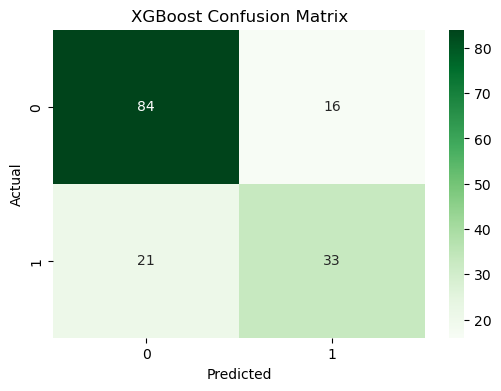

In [24]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [25]:
# ============================================================
# 11. Cross Validation
# ============================================================

lgbm_cv = cross_val_score(
    lgbm_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

xgb_cv = cross_val_score(
    xgb_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nLightGBM CV Accuracy:", lgbm_cv.mean())
print("XGBoost CV Accuracy :", xgb_cv.mean())

[LightGBM] [Info] Number of positive: 214, number of negative: 400
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 666
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348534 -> initscore=-0.625489
[LightGBM] [Info] Start training from score -0.625489
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [26]:
# ============================================================
# 12. Hyperparameter Tuning - LightGBM
# ============================================================

lgbm_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42),
    lgbm_params,
    cv=3,
    scoring='accuracy'
)

grid_lgbm.fit(X_train, y_train)

print("\nBest LightGBM Parameters:")
print(grid_lgbm.best_params_)

print("Best LightGBM Accuracy:")
print(grid_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 143, number of negative: 266
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000071 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.349633 -> initscore=-0.620652
[LightGBM] [Info] Start training from score -0.620652
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

In [27]:
# ============================================================
# 13. Hyperparameter Tuning - XGBoost
# ============================================================

xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    xgb_params,
    cv=3,
    scoring='accuracy'
)

grid_xgb.fit(X_train, y_train)

print("\nBest XGBoost Parameters:")
print(grid_xgb.best_params_)

print("Best XGBoost Accuracy:")
print(grid_xgb.best_score_)


Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 50}
Best XGBoost Accuracy:
0.7541447473298263


In [28]:
# ============================================================
# 14. Comparative Analysis
# ============================================================

comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lgbm),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lgbm),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lgbm),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lgbm),
        f1_score(y_test, y_pred_xgb)
    ]
})

print("\nModel Comparison:")
print(comparison)


Model Comparison:
      Model  Accuracy  Precision    Recall  F1 Score
0  LightGBM  0.727273   0.620000  0.574074  0.596154
1   XGBoost  0.759740   0.673469  0.611111  0.640777


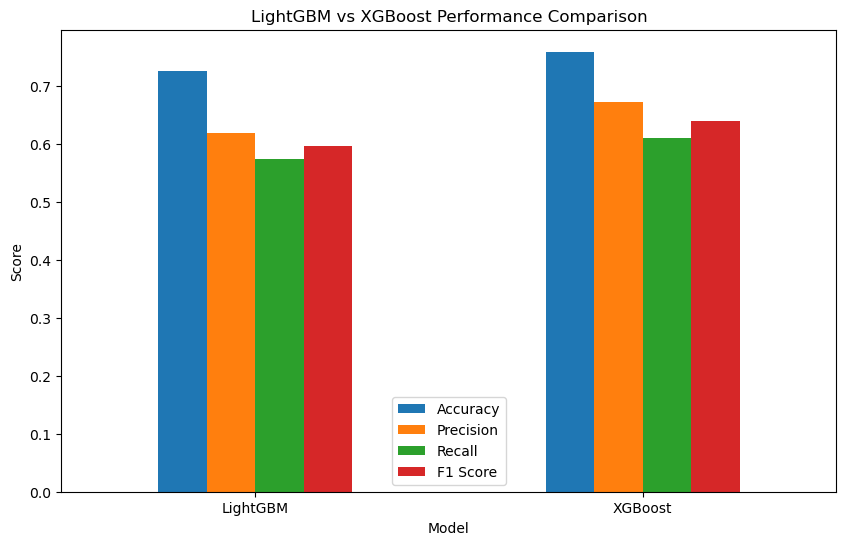

In [29]:
# ============================================================
# 15. Visualization of Model Comparison
# ============================================================

comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("LightGBM vs XGBoost Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()